# Reward-Component Ablation

## Abstract

The combined run of notebook 11 suggested that most reward terms do not change what the agent generates. This notebook tests that systematically. The full six-term reward is compared to six leave-one-out variants and to an activity-only reward, each run over five independent REINVENT replicates and evaluated on reward-independent, per-term metrics. Activity is the only strong driver: removing it lowers the predicted activity from 5.63 to 5.45 and collapses scaffold diversity from 0.85 to 0.67. The logD and QED terms bind weakly; synthetic accessibility, xTB viability and the novelty term sit within replicate noise. The activity-only reward reaches both higher activity (5.88) and higher scaffold diversity (0.95) than the full reward, so the auxiliary guardrails slightly suppress both. In drug-like space, a good prior and an activity term do most of the work.

## Introduction

A reward that stacks many terms is only justified if each term changes the output. Notebook 11 hinted otherwise. Here each term is removed one at a time from the full reward, and the effect is measured on the generated molecules rather than on the reward the run optimized. An activity-only condition isolates the activity term, and a prior-only sample sets the floor.

## Methods

Seven conditions were run: the full six-term reward and six leave-one-out variants, each removing one term. Each of the seven conditions was run five times (five independent replicates per condition, 35 runs in total). REINVENT does not fix a random seed, so these are independent stochastic runs rather than paired seeds, which makes the comparison unpaired. Terms are combined by a renormalized geometric mean, so removing a term also reweights the others, an effect kept in mind when reading the results. Each condition was run over five independent REINVENT replicates at equal oracle budget (no fixed seed, so the comparison is unpaired). For each run, the final population (last 25% of steps) was scored on reward-independent metrics computed with the frozen ensemble and surrogates: predicted activity μ, QED, synthetic accessibility, xTB viability, the fraction of molecules with predicted logD in the 1 to 3 window, novelty (one minus the maximum Tanimoto to the training set), scaffold diversity, validity and uniqueness. An activity-only reward was run for reference.

In [8]:
import sys, os, glob, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
REPO = "/mnt/c/Users/coure/Projects/cheminformatics"
sys.path.append(REPO)
from scoring.scorer import ensemble, xtb_clf, LIPO, feat, compute_fp, ref_fps
from rdkit import Chem, DataStructs
from rdkit.Chem import QED, RDConfig
from rdkit.Chem.Scaffolds import MurckoScaffold
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score")); import sascorer

from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

plt.rcParams["figure.dpi"] = 80     
plt.rcParams["font.size"] = 9       
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 8

In [9]:
BATCH = 64
def load_run(path):                      
    df = pd.read_csv(path).dropna(subset=["SMILES"]).reset_index(drop=True)
    df["step"] = np.arange(len(df)) // BATCH
    return df[df["step"] >= df["step"].max()*0.75]["SMILES"].tolist()

def metrics(smiles):
    mols = [Chem.MolFromSmiles(s) for s in smiles]
    valid = [m for m in mols if m is not None]
    r = {"validity": len(valid)/len(smiles), "uniqueness": len(set(smiles))/len(smiles)}
    if not valid: return r
    X = np.vstack([feat(m) for m in valid])
    preds = np.stack([mm.predict(X) for mm in ensemble])
    r["activity_mu"] = float(preds.mean(0).mean())          
    r["qed"]     = float(np.mean([QED.qed(m) for m in valid]))
    r["sa_des"]  = float(np.mean([(10-sascorer.calculateScore(m))/9 for m in valid]))
    Xfp = np.array([np.asarray(compute_fp(m)) for m in valid])
    r["xtb_viab"] = float(np.mean(1 - xtb_clf.predict_proba(Xfp)[:,1]))
    logd = LIPO.predict(X)
    r["logd_inwin"] = float(np.mean((logd>=1)&(logd<=3)))    
    r["novelty"] = float(np.mean([1-max(DataStructs.BulkTanimotoSimilarity(compute_fp(m), ref_fps)) for m in valid]))
    scaf = {MurckoScaffold.MurckoScaffoldSmiles(mol=m) for m in valid}
    r["scaffold_div"] = len(scaf)/len(valid)
    return r

## Results

The per-term comparison removes one term at a time and reads its own target metric. Activity is the largest single effect: removing it lowers the predicted activity from 5.628 to 5.447. The logD window and QED bind weakly, their target metrics falling from 0.661 to 0.597 and from 0.793 to 0.758 when removed. Synthetic accessibility, xTB viability and novelty move by less than the replicate noise.

The effect-size map shows each condition's deviation from the full reward in units of replicate noise. The diagonal confirms the ranking: removing activity, QED or logD lowers the corresponding metric by 1.3 to 1.8 noise units, while removing synthetic accessibility, xTB viability or the applicability-domain term stays within noise. The map also exposes a side effect: removing activity collapses scaffold diversity by 2.2 noise units. The activity-only row is the strongest signal in the figure. Dropping every guardrail at once raises activity by 2.6 noise units but lowers QED by 3.2, xTB viability by 2.7, synthetic accessibility by 1.4 and the logD fraction by 1.3.

The activity trajectory makes the driver visible. The activity-only run reaches the highest predicted activity and the drop-activity run the lowest, while every other ablation tracks the full reward closely.

In [10]:
rows = []
for path in sorted(glob.glob(f"{REPO}/rl_runs/ablation/abl_*_1.csv")):
    cond, rep = re.match(r"abl_(.+)_s(\d)_1\.csv", os.path.basename(path)).groups()
    r = metrics(load_run(path)); r.update(condition=cond, rep=int(rep))
    rows.append(r)
res = pd.DataFrame(rows)
metric_cols = ["activity_mu","qed","sa_des","xtb_viab","logd_inwin","novelty","scaffold_div","validity","uniqueness"]
agg = res.groupby("condition")[metric_cols].agg(["mean","std"])
order = ["full"] + [f"drop_{t}" for t in ["activity","qed","ad","sa","xtb","logd"]] + ["activity_only"]
agg = agg.reindex(order)
agg.round(3)

activity_mu           qed        sa_des        xtb_viab         \
                     mean    std   mean    std   mean    std     mean    std   
condition                                                                      
full                5.628  0.138  0.793  0.018  0.826  0.016    0.971  0.003   
drop_activity       5.447  0.152  0.794  0.016  0.844  0.022    0.974  0.004   
drop_qed            5.629  0.104  0.758  0.041  0.839  0.023    0.972  0.002   
drop_ad             5.487  0.116  0.791  0.014  0.823  0.025    0.972  0.002   
drop_sa             5.606  0.043  0.779  0.020  0.816  0.030    0.975  0.003   
drop_xtb            5.586  0.089  0.786  0.011  0.840  0.020    0.974  0.002   
drop_logd           5.528  0.062  0.793  0.013  0.837  0.009    0.971  0.004   
activity_only       5.884  0.081  0.719  0.048  0.796  0.028    0.962  0.008   

              logd_inwin        novelty        scaffold_div        validity  \
                    mean    std    mean    std         mean    std     mean   
condition                                                                     
full               0.661  0.030   0.720  0.010        0.847  0.081    0.990   
drop_activity      0.632  0.043   0.716  0.014        0.668  0.120    0.992   
drop_qed           0.583  0.055   0.710  0.018        0.824  0.099    0.990   
drop_ad            0.639  0.023   0.727  0.022        0.742  0.119    0.990   
drop_sa            0.624  0.079   0.729  0.016        0.815  0.055    0.991   
drop_xtb           0.649  0.041   0.714  0.010        0.799  0.080    0.992   
drop_logd          0.597  0.018   0.716  0.006        0.745  0.051    0.992   
activity_only      0.597  0.094   0.732  0.011        0.947  0.053    0.981   

                     uniqueness         
                 std       mean    std  
condition                               
full           0.003      1.000  0.000  
drop_activity  0.001      0.994  0.005  
drop_qed       0.002      0.995  0.010  
drop_ad        0.005      0.993  0.014  
drop_sa        0.004      0.999  0.001  
drop_xtb       0.002      0.996  0.005  
drop_logd      0.003      0.998  0.003  
activity_only  0.007      1.000  0.000

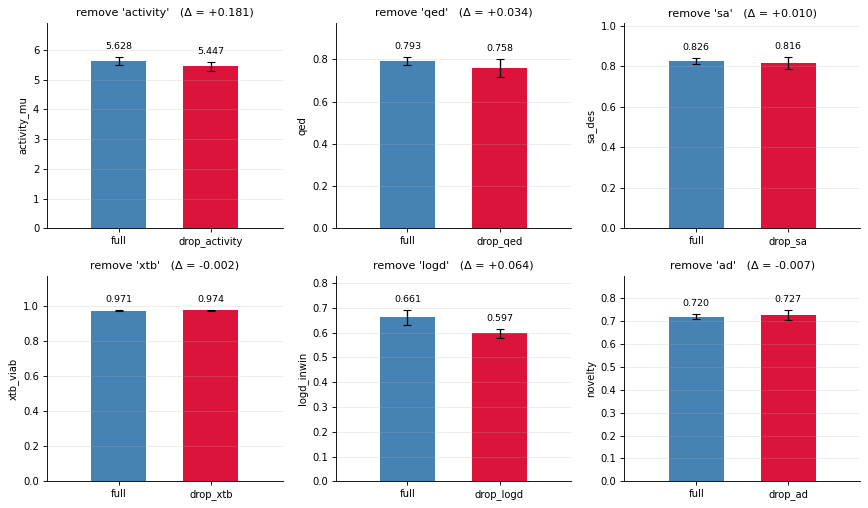

In [11]:
target = {"activity":"activity_mu","qed":"qed","sa":"sa_des","xtb":"xtb_viab","logd":"logd_inwin","ad":"novelty"}
fig, axes = plt.subplots(2, 3, figsize=(11, 6.5))
for ax, (t, col) in zip(axes.ravel(), target.items()):
    conds = ["full", f"drop_{t}"]
    means = [res[res.condition == c][col].mean() for c in conds]
    stds  = [res[res.condition == c][col].std()  for c in conds]
    ax.bar(conds, means, yerr=stds, capsize=4, width=0.6,
           color=["steelblue", "crimson"], error_kw={"elinewidth": 1.2})
    top = max(m + s for m, s in zip(means, stds))
    ax.set_ylim(0, top * 1.20)                                  # headroom for the labels
    for x, (m, s) in enumerate(zip(means, stds)):
        ax.text(x, m + s + top * 0.035, f"{m:.3f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_ylabel(col)
    ax.set_title(f"remove '{t}'   (Δ = {means[0] - means[1]:+.3f})", fontsize=10)
    ax.margins(x=0.3)
    ax.grid(axis="y", alpha=0.25)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
plt.tight_layout(pad=1.4)
plt.show()

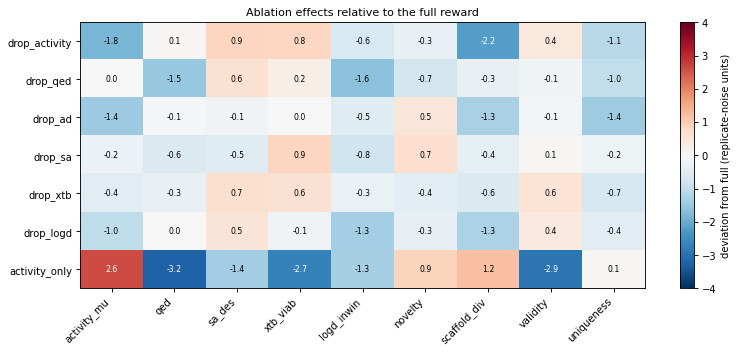

In [12]:
means = agg.xs("mean", axis=1, level=1)
pooled_std = res.groupby("condition")[metric_cols].std().mean()   # typical replicate noise per metric
eff = (means - means.loc["full"]) / pooled_std                    # deviation from 'full', in noise units
eff = eff.drop(index="full")

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(eff.values, cmap="RdBu_r", vmin=-4, vmax=4, aspect="auto")
ax.set_xticks(range(len(eff.columns))); ax.set_xticklabels(eff.columns, rotation=45, ha="right")
ax.set_yticks(range(len(eff.index)));   ax.set_yticklabels(eff.index)
for i in range(eff.shape[0]):
    for j in range(eff.shape[1]):
        ax.text(j, i, f"{eff.values[i,j]:.1f}", ha="center", va="center", fontsize=7,
                color="white" if abs(eff.values[i,j]) > 2 else "black")
plt.colorbar(im, label="deviation from full (replicate-noise units)")
ax.set_title("Ablation effects relative to the full reward")
plt.tight_layout(); plt.show()

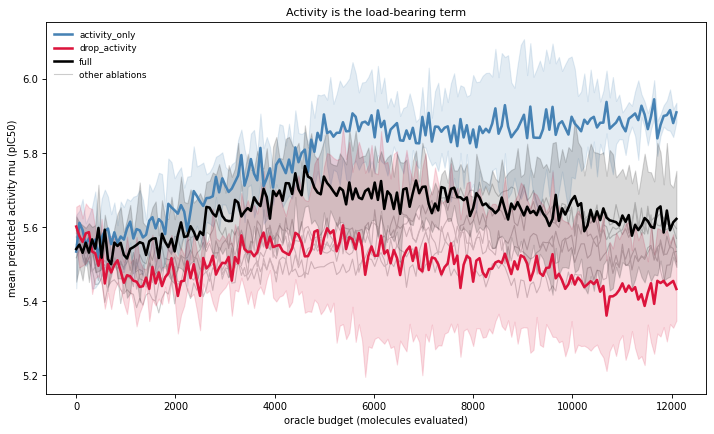

In [13]:
def per_step_mu(path):
    d = pd.read_csv(path).dropna(subset=["SMILES"]).reset_index(drop=True)
    d["step"] = np.arange(len(d)) // BATCH
    mols = [Chem.MolFromSmiles(s) for s in d["SMILES"]]
    ok = [i for i, m in enumerate(mols) if m is not None]
    X = np.vstack([feat(mols[i]) for i in ok])
    mu = np.stack([mm.predict(X) for mm in ensemble]).mean(0)          # mu per molecule
    return pd.DataFrame({"step": d["step"].values[ok], "mu": mu}).groupby("step")["mu"].mean()

# compute the per-step activity curve for every run (a few minutes)
curves = {}
for path in sorted(glob.glob(f"{REPO}/rl_runs/ablation/abl_*_1.csv")):
    cond, rep = re.match(r"abl_(.+)_s(\d)_1\.csv", os.path.basename(path)).groups()
    curves.setdefault(cond, {})[int(rep)] = per_step_mu(path)

key = {"full": "black", "drop_activity": "crimson", "activity_only": "steelblue"}
plt.figure(figsize=(9, 5.5))
for cond, reps in sorted(curves.items()):
    M = pd.DataFrame(reps).sort_index()
    mean, std = M.mean(axis=1), M.std(axis=1)
    x = mean.index * BATCH
    if cond in key:
        plt.plot(x, mean.values, color=key[cond], lw=2.3, zorder=3, label=cond)
        plt.fill_between(x, mean - std, mean + std, color=key[cond], alpha=0.15, zorder=2)
    else:
        plt.plot(x, mean.values, color="0.8", lw=1, zorder=1)
plt.plot([], [], color="0.8", lw=1, label="other ablations")
plt.xlabel("oracle budget (molecules evaluated)")
plt.ylabel("mean predicted activity mu (pIC50)")
plt.title("Activity is the load-bearing term")
plt.legend(frameon=False)
plt.tight_layout(); plt.show()

## Discussion

Two readings must be held together. Taken one at a time, most terms barely bind. Only activity, and to a lesser extent QED and logD, move their own metric beyond the replicate noise, and synthetic accessibility, xTB viability and novelty do not. Taken together, the guardrails matter. The activity-only condition, which removes all of them, reaches much higher activity but pays for it with sharp drops in QED, xTB viability, synthetic accessibility and the logD window. The resolution is redundancy. Each guardrail overlaps with the prior, the structural guards and the other terms, so removing any single one is absorbed by the rest, while removing all of them lets the agent trade drug-likeness for raw activity. A leave-one-out study therefore understates each term. The honest conclusion is that the guardrails are individually redundant but collectively load-bearing. 

Activity also governs diversity. Removing it collapses scaffold diversity, and optimizing it alone gives the most diverse population. An active target admits a large, varied set of solutions, so activity keeps generation broad, the guardrails prune it, and without activity the agent converges on a narrow, easy drug-like region. 

Three caveats bound these conclusions. The renormalized geometric mean means that a leave-one-out effect mixes the removal of one term with the reweighting of the rest. Five independent replicates per condition give low power, so only effects larger than the replicate noise are read, which is why results are reported as effect sizes and not significance tests. Finally, the validity and uniqueness columns sit near 1.0 in every condition, so their large values in noise units reflect a very small absolute change and should not be over-read.

## Conclusion

This ablation measures the contribution of each reward term instead of assuming it. Activity is load-bearing and also drives diversity; logD and QED contribute weakly; synthetic accessibility, xTB viability and novelty are largely redundant on drug-like molecules. The practical lesson is that stacking guardrails yields diminishing returns here, and that making them bind would require pushing generation outside the prior's comfortable region, for example with an explicit novelty or exploration objective.